# Solar Eclipses

What is the average duration of total darkness during a total solar eclipse? When did the longest solar eclipse occur?

The file `solar-eclipses.csv` provides information on all solar eclipses from 1901 to 2100, leveraging the ability of scientists to accurately predict the timing and location of future eclipses.

A solar eclipse happens when the Moon moves between the Earth and the Sun, blocking the Sun's light either partially or completely. There are three primary types of solar eclipses:

1. Total Solar Eclipse: The Moon fully covers the Sun, casting a shadow on Earth and revealing the Sun's corona.

2. Partial Solar Eclipse: The Moon obscures only part of the Sun, creating a crescent-shaped appearance.

3. Annular Solar Eclipse: The Moon covers the center of the Sun, leaving a ring-like appearance, known as a "ring of fire," around the edges. This occurs when the Moon is too far from Earth to completely cover the Sun.

The `duration` variable indicates the length of time that the entire moon covers the sun.


In [1]:
# FOR GOOGLE COLAB ONLY.
# Uncomment and run the code below. A dialog will appear to upload files.
# Upload 'solar-eclipses.csv'.

# from google.colab import files
# uploaded = files.upload()

In [2]:
import pandas as pd
pd.set_option('display.max_colwidth', 1000)
df = pd.read_csv('solar-eclipses.csv')
df

,date,eclipse_type,magnitude,duration,region
0,05-18-1901,Total,1.068,06m29s,"s Asia, Australia, e Africa [Total: Indonesia, N Guinea, Madagascar]"
1,11-11-1901,Annular,0.922,11m01s,"ne Africa, Asia, w Europe [Annular: ne Africa, India, Sri Lanka, se Asia]"
2,04-08-1902,Partial,0.064,NaN,northern Canada
3,05-07-1902,Partial,0.859,NaN,"New Zealand, South Pacific"
4,10-31-1902,Partial,0.696,NaN,"c Asia, e Europe"
...,...,...,...,...,...
439,10-24-2098,Partial,0.006,NaN,Southern Ocean (near Antarctica)
440,03-21-2099,Annular,0.932,07m32s,"Australia, N.Z., Antarctica, N. America [Annular: Central Pacific]"
441,09-14-2099,Total,1.068,05m18s,"Americas, Africa [Total: Canada, U.S., Central Atlantic]"
442,03-10-2100,Annular,0.934,07m29s,"Australia, N. America [Annular: Central Pacific, U.S.]"


### Project Ideas:

- When did the longest solar eclipse occur? The longest total eclipse?
	- Hint: convert duration to seconds. You can use `str.replace('s', '')` to remove the 's' from the duration values.

- What is the average duration of total solar eclipses? 

- Show the next 10 solar eclipses?
	- Hint: convert date to datetime.


In [3]:
# YOUR CODE HERE (add additional cells as needed)

In [4]:
def duration_to_seconds(x):

    if pd.isna(x):
        return None

    x = x.replace("s", "")

    minutes, seconds = x.split("m")

    total_seconds = (
        int(minutes) * 60
        + int(seconds)
    )

    return total_seconds

In [5]:
df["duration_seconds"] = df[
    "duration"
].apply(duration_to_seconds)

In [7]:
longest = df.loc[df.duration_seconds.idxmax()]
print(longest)

date                                                                                                                                     12-14-1955
eclipse_type                                                                                                                                Annular
magnitude                                                                                                                                     0.918
duration                                                                                                                                     12m09s
region              c & e Africa, Mid East, Asia, East Indies [Annular: Chad, Sudan, Ethiopia, Somalia, Myanmar, Thailand, Laos, Vietnam, se China]
duration_seconds                                                                                                                              729.0
Name: 126, dtype: object


In [8]:
print(
    longest[
        [
            "date",
            "eclipse_type",
            "duration",
            "region"
        ]
    ]
)

date                                                                                                                                 12-14-1955
eclipse_type                                                                                                                            Annular
duration                                                                                                                                 12m09s
region          c & e Africa, Mid East, Asia, East Indies [Annular: Chad, Sudan, Ethiopia, Somalia, Myanmar, Thailand, Laos, Vietnam, se China]
Name: 126, dtype: object


In [10]:
total_eclipses = df[
    df["eclipse_type"] == "Total"
]
print(f"Total eclipses: {len(total_eclipses)}")

Total eclipses: 135


In [11]:
longest_total = total_eclipses.loc[
    total_eclipses[
        "duration_seconds"
    ].idxmax()
]

print(longest_total)

date                                                                                                                            06-20-1955
eclipse_type                                                                                                                         Total
magnitude                                                                                                                            1.078
duration                                                                                                                            07m08s
region              e Africa, e Asia, East Indies, n Australia [Total: Sri Lanka, Myanmar, Thailand, Laos, Cambodia, Vietnam, Philippines]
duration_seconds                                                                                                                     428.0
Name: 125, dtype: object


In [12]:
avg_total = total_eclipses[
    "duration_seconds"
].mean()

print(avg_total)

211.96296296296296


In [13]:
df["date"] = pd.to_datetime(
    df["date"],
    format="%m-%d-%Y"
)

In [14]:
df = df.sort_values("date")

In [15]:
today = pd.Timestamp.today()

future = df[
    df["date"] > today
]

In [16]:
next10 = future.head(10)

print(next10)

          date eclipse_type  magnitude duration  \
277 2026-08-12        Total      1.039   02m18s   
278 2027-02-06      Annular      0.928   07m51s   
279 2027-08-02        Total      1.079   06m23s   
280 2028-01-26      Annular      0.921   10m27s   
281 2028-07-22        Total      1.056   05m10s   
282 2029-01-14      Partial      0.871      NaN   
283 2029-06-12      Partial      0.458      NaN   
284 2029-07-11      Partial      0.230      NaN   
285 2029-12-05      Partial      0.891      NaN   
286 2030-06-01      Annular      0.944   05m21s   

                                                                                                                    region  \
277                                              n N. America, w Africa, Europe [Total: Arctic, Greenland, Iceland, Spain]   
278                                             S. America, Antarctica, w & s Africa [Annular: Chile, Argentina, Atlantic]   
279       Africa, Europe, Mid East, w & s Asia [Total:Morocc

In [17]:
print(
    next10[
        [
            "date",
            "eclipse_type",
            "magnitude",
            "region"
        ]
    ]
)

          date eclipse_type  magnitude  \
277 2026-08-12        Total      1.039   
278 2027-02-06      Annular      0.928   
279 2027-08-02        Total      1.079   
280 2028-01-26      Annular      0.921   
281 2028-07-22        Total      1.056   
282 2029-01-14      Partial      0.871   
283 2029-06-12      Partial      0.458   
284 2029-07-11      Partial      0.230   
285 2029-12-05      Partial      0.891   
286 2030-06-01      Annular      0.944   

                                                                                                                    region  
277                                              n N. America, w Africa, Europe [Total: Arctic, Greenland, Iceland, Spain]  
278                                             S. America, Antarctica, w & s Africa [Annular: Chile, Argentina, Atlantic]  
279       Africa, Europe, Mid East, w & s Asia [Total:Morocco, Spain, Algeria, Libya, Egypt, Saudi Arabia, Yemen, Somalia]  
280         e N. America, C. & S. Ame

<Axes: xlabel='eclipse_type'>

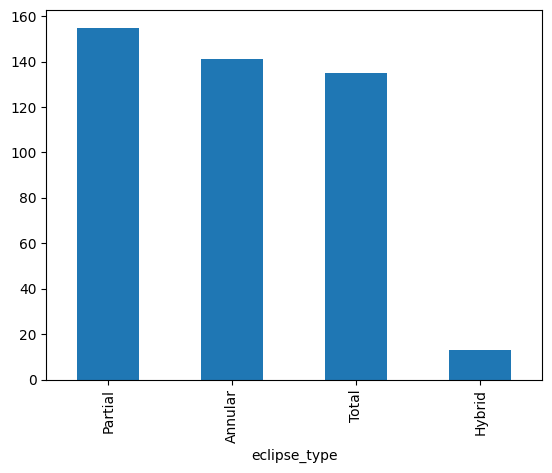

In [18]:
df["eclipse_type"].value_counts().plot.bar()

<Axes: ylabel='Frequency'>

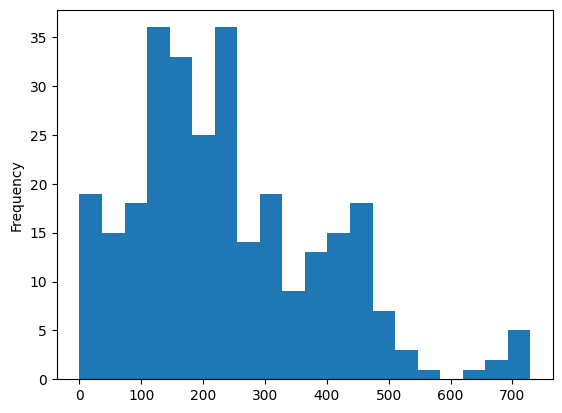

In [19]:
df["duration_seconds"].plot.hist(
    bins=20
)

<Axes: xlabel='year'>

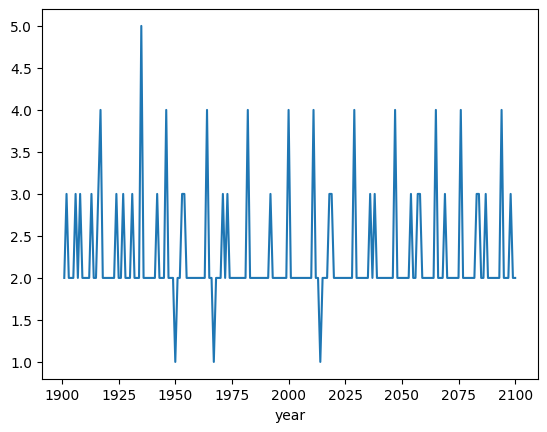

In [20]:
df["year"] = df["date"].dt.year

df.groupby("year").size().plot()

<Axes: xlabel='date'>

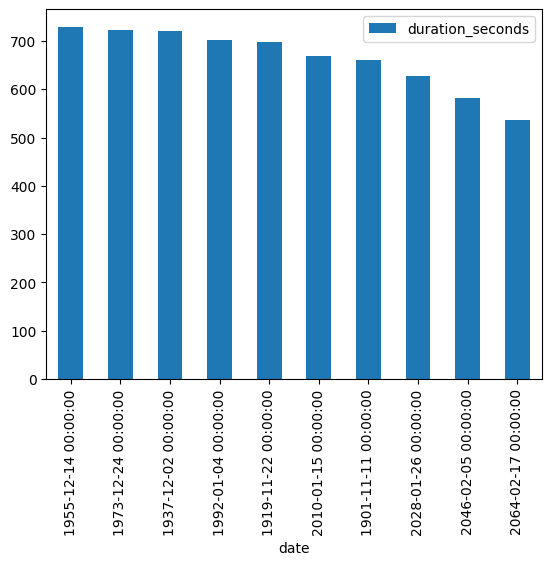

In [21]:
top10 = df.sort_values(
    "duration_seconds",
    ascending=False
).head(10)

top10.plot.bar(
    x="date",
    y="duration_seconds"
)

In [22]:
df.groupby(
    "eclipse_type"
)["duration_seconds"].mean()

eclipse_type
Annular    288.510638
Hybrid      30.769231
Partial           NaN
Total      211.962963
Name: duration_seconds, dtype: float64

In [23]:
df[
    ["magnitude", "duration_seconds"]
].corr()

,magnitude,duration_seconds
magnitude,1.000000,-0.414004
duration_seconds,-0.414004,1.000000
